and gate predictions (should be [0 0 0 1]):  
 [0 0 0 1]
xor gate predictions (fails to learn): 
 [1 1 0 0]


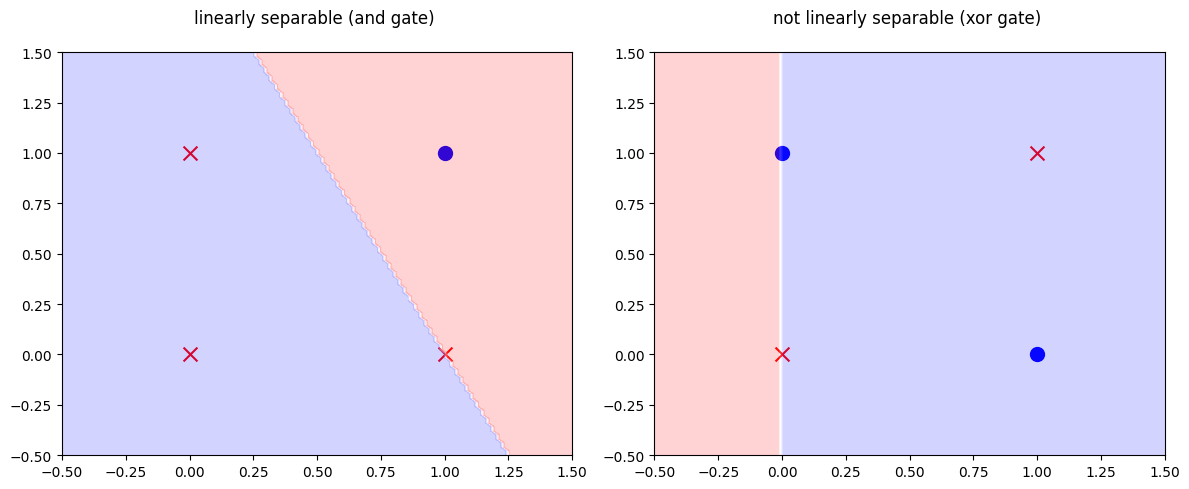

exoplaination
 The perceptron, by its design, can only find linear decision boundaries,
which is why it cannot solve the XOR problem. This limitation led to the development of multi-layer perceptrons (neural networks) which can learn non-linear decision boundaries.



In [4]:
import numpy as np
import matplotlib.pyplot as plt

#1.perceptron model definition
class perceptron:
    def __init__(self, learning_rate=0.1, epochs=50):
        # initialize hyperparameters
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def activation(self, x):
        # step function: return 1 if x >= 0 else 0
        return np.where(x >= 0, 1, 0)

    def fit(self, x, y):
        n_samples, n_features = x.shape

        #initialize weights and bias to zeros
        self.weights = np.zeros(n_features)
        self.bias = 0

        # training loop
        for _ in range(self.epochs):
            for idx, x_i in enumerate(x):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation(linear_output)

                # perceptron learning rule
                update = self.lr * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

    def predict(self, x):
        # calculate final predictions
        linear_output = np.dot(x, self.weights) + self.bias
        return self.activation(linear_output)


#2. dataset creation
#dataset 1:AND gate (linearly separable data)
x_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

#dataset 2:XOR gate (not linearly separable)
x_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])


#3.model training and testin
#train and test on the linearly separable data
model_and = perceptron(learning_rate=0.1, epochs=10)
model_and.fit(x_and, y_and)
print("and gate predictions (should be [0 0 0 1]):  \n", model_and.predict(x_and))

#train and test on the non-linearly separable data
model_xor = perceptron(learning_rate=0.1, epochs=50)
model_xor.fit(x_xor, y_xor)
print("xor gate predictions (fails to learn): \n", model_xor.predict(x_xor))


#4. visualization
def plot_decision_boundary(x, y, model, ax, title):
    #plot the actual data points
    for i, point in enumerate(x):
        if y[i] == 1:
            ax.scatter(point[0], point[1], color='blue', marker='o', s=100, label='class 1' if i==3 else "")
        else:
            ax.scatter(point[0], point[1], color='red', marker='x', s=100, label='class 0' if i==0 else "")

    #create a mesh grid to visualize the decision boundary
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    #get predictions for every point on the grid
    predictions = model.predict(grid_points).reshape(xx.shape)

    #plot the background colors based on predictions
    ax.contourf(xx, yy, predictions, alpha=0.2, cmap='bwr')
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

#plotting results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(x_and, y_and, model_and, ax1, 'linearly separable (and gate) \n')
plot_decision_boundary(x_xor, y_xor, model_xor, ax2, 'not linearly separable (xor gate) \n')
plt.tight_layout()
plt.show()
#results explained
print("exoplaination\n The perceptron, by its design, can only find linear decision boundaries,")
print("which is why it cannot solve the XOR problem. This limitation led to the development of multi-layer perceptrons (neural networks) which can learn non-linear decision boundaries.\n")


and gate predictions (should be [[0] [0] [0] [1]]):
[[0.]
 [0.]
 [0.]
 [1.]]

xor gate predictions (should be [[0] [1] [1] [0]]):
[[0.]
 [1.]
 [1.]
 [0.]]


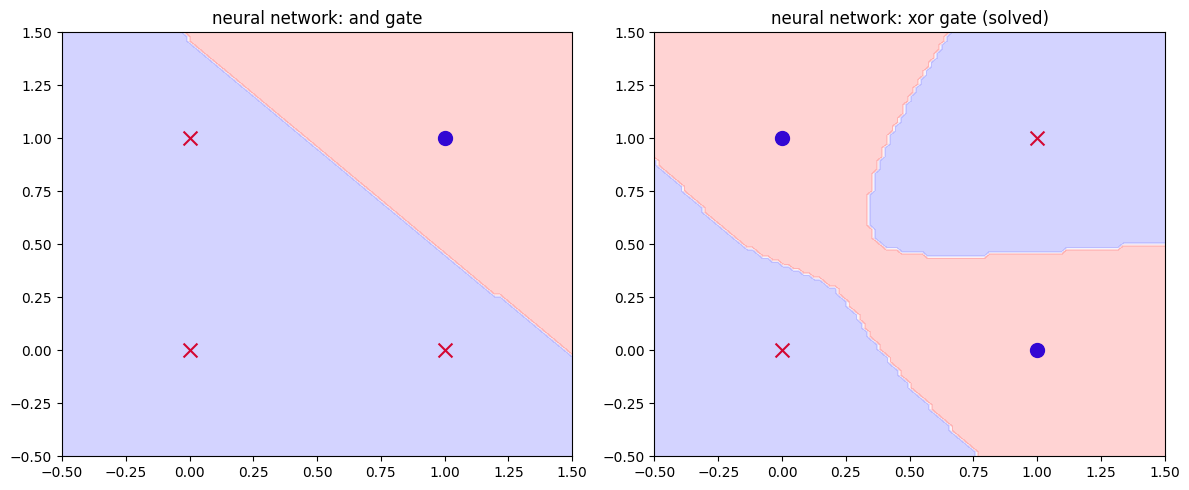



 Explaination-
role of the activation function- helps in th eclassification by intorducing non-linearity. here we are using sigmoid.
Altenatives to sigmoid function - tanh, relu or leaky-relu.
how hidden layers work- 
The key to hidden layers is the use of non-linear activation functions (like sigmoid, Tanh, ReLU) within each neuron.
If we only used linear activation functions, stacking multiple layers would still result in a linear model, as a composition of linear functions is always linear.

Each hidden layer effectively transforms the input data into a new, higher-dimensional (or at least different) feature space. 
Imagine taking your original 2D data points (like the XOR inputs) and projecting them into a 3D space. 
In this new space, the previously non-linearly separable points might become linearly separable.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

#1. multi-layer neural network definition
class neural_network:
    def __init__(self, input_nodes=2, hidden1_nodes=4, hidden2_nodes=4, output_nodes=1, lr=0.5, epochs=10000):
        #initialize hyperparameters- epochs and learning rate(lr)
        self.lr = lr
        self.epochs = epochs

        #initialize weights and biases with random/arbitrary  values
        self.w1 = np.random.uniform(-1, 1, (input_nodes, hidden1_nodes))
        self.b1 = np.zeros((1, hidden1_nodes))

        self.w2 = np.random.uniform(-1, 1, (hidden1_nodes, hidden2_nodes))
        self.b2 = np.zeros((1, hidden2_nodes))

        self.w3 = np.random.uniform(-1, 1, (hidden2_nodes, output_nodes))
        self.b3 = np.zeros((1, output_nodes))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        #derivative of sigmoid: f(x) * (1 - f(x))
        #note: here x is already the output of the sigmoid function
        return x * (1 - x)

    def fit(self, x, y):
        for _ in range(self.epochs):
            #forward propagation
            z1 = np.dot(x, self.w1) + self.b1
            a1 = self.sigmoid(z1)

            z2 = np.dot(a1, self.w2) + self.b2
            a2 = self.sigmoid(z2)

            z3 = np.dot(a2, self.w3) + self.b3
            a3 = self.sigmoid(z3)

            #backward propagation (using mean squared error)
            error = a3 - y

            #layer 3 gradients
            dz3 = error * self.sigmoid_derivative(a3)
            dw3 = np.dot(a2.T, dz3)
            db3 = np.sum(dz3, axis=0, keepdims=1)

            #layer 2 gradients
            da2 = np.dot(dz3, self.w3.T)
            dz2 = da2 * self.sigmoid_derivative(a2)
            dw2 = np.dot(a1.T, dz2)
            db2 = np.sum(dz2, axis=0, keepdims=1)

            #layer 1 gradients
            da1 = np.dot(dz2, self.w2.T)
            dz1 = da1 * self.sigmoid_derivative(a1)
            dw1 = np.dot(x.T, dz1)
            db1 = np.sum(dz1, axis=0, keepdims=1)

            #update weights and biases
            self.w3 -= self.lr * dw3
            self.b3 -= self.lr * db3
            self.w2 -= self.lr * dw2
            self.b2 -= self.lr * db2
            self.w1 -= self.lr * dw1
            self.b1 -= self.lr * db1

    def predict(self, x):
        #forward pass for final prediction
        z1 = np.dot(x, self.w1) + self.b1
        a1 = self.sigmoid(z1)
        z2 = np.dot(a1, self.w2) + self.b2
        a2 = self.sigmoid(z2)
        z3 = np.dot(a2, self.w3) + self.b3
        a3 = self.sigmoid(z3)
        return np.round(a3)

#2.dataset
#inputs for logic gates
x_data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
#outputs
y_and = np.array([[0], [0], [0], [1]])
y_xor = np.array([[0], [1], [1], [0]])

#3.model trainin
#train AND network
nn_and = neural_network(lr=0.5, epochs=5000)
nn_and.fit(x_data, y_and)
print("and gate predictions (should be [[0] [0] [0] [1]]):")
print(nn_and.predict(x_data))

#train XOR network
nn_xor = neural_network(lr=0.5, epochs=10000)
nn_xor.fit(x_data, y_xor)
print("\nxor gate predictions (should be [[0] [1] [1] [0]]):")
print(nn_xor.predict(x_data))

#4.visualization
def plot_decision_boundary(x, y, model, ax, title):
    #the actual data points
    for i, point in enumerate(x):
        #flatten y for simple indexing
        if y[i][0] == 1:
            ax.scatter(point[0], point[1], color='blue', marker='o', s=100)
        else:
            ax.scatter(point[0], point[1], color='red', marker='x', s=100)

    #create a mesh grid to visualize the decision boundary
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    #get predictions for every point on the grid
    predictions = model.predict(grid_points).reshape(xx.shape)

    #plot the background colors based on predictions
    ax.contourf(xx, yy, predictions, alpha=0.2, cmap='bwr')
    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(x_data, y_and, nn_and, ax1, 'neural network: and gate')
plot_decision_boundary(x_data, y_xor, nn_xor, ax2, 'neural network: xor gate (solved)')
plt.tight_layout()
plt.show()

#explainantions
print("\n\n Explaination-\nrole of the activation function- helps in th eclassification by intorducing non-linearity. here we are using sigmoid.")
print("Altenatives to sigmoid function - tanh, relu or leaky-relu.")
print("how hidden layers work- ")
print("The key to hidden layers is the use of non-linear activation functions (like sigmoid, Tanh, ReLU) within each neuron.")
print("If we only used linear activation functions, stacking multiple layers would still result in a linear model, as a composition of linear functions is always linear.\n")
print('''Each hidden layer effectively transforms the input data into a new, higher-dimensional (or at least different) feature space.
Imagine taking your original 2D data points (like the XOR inputs) and projecting them into a 3D space.
In this new space, the previously non-linearly separable points might become linearly separable.''')

training model 1: 30 hidden layers, 16 neurons each.
training model 2: 3 hidden layers, 16 neurons each.
training model 3: 3 hidden layers, 128 neurons each.

final test accuracies
model 1 (30 layers, 16 neurons): 0.9238
model 2 (3 layers, 16 neurons) : 0.9401
model 3 (3 layers, 128 neurons): 0.9729


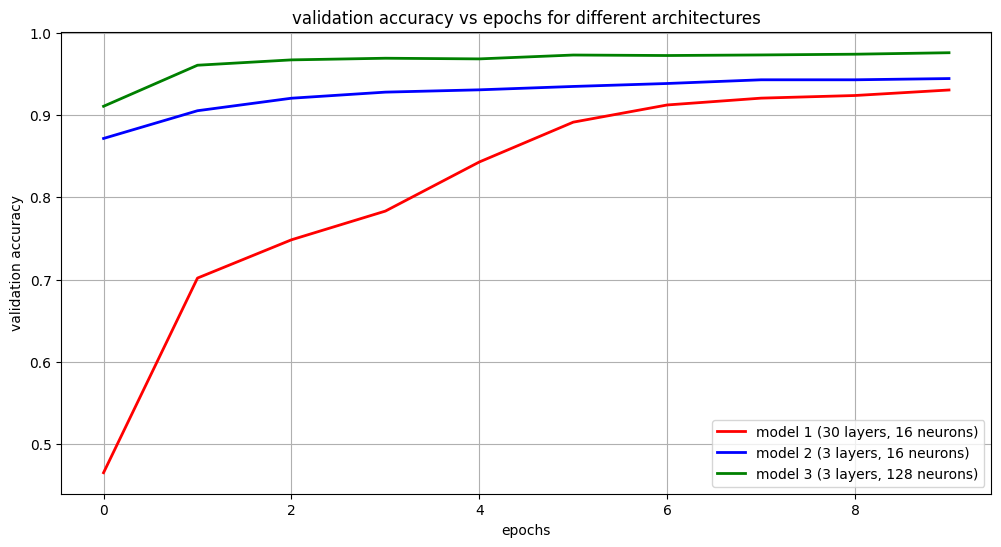

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential as sequential
from tensorflow.keras.layers import Dense as dense, Flatten as flatten, BatchNormalization as batchnormalization, Dropout as dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam as adam
from tensorflow.keras.utils import to_categorical as to_categorical

#2]import dataset and divide into train, validation, test
#we use the standard mnist digit classification dataset
(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()

#normalize pixel values to be between 0 and 1(batch normalization)
x_train_full = x_train_full / 255.0
x_test_full = x_test_full / 255.0

#divide the 60,000 training images into 50,000 train and 10,000 validation
x_train = x_train_full[:50000]
y_train = y_train_full[:50000]
x_val = x_train_full[50000:]
y_val = y_train_full[50000:]

x_test = x_test_full
y_test = y_test_full

#one-hot encode the labels (0-9 digits)
y_train = to_categorical(y_train, 10)
y_val = to_categorical(y_val, 10)
y_test = to_categorical(y_test, 10)

#helper function to build models dynamically
def build_model(num_hidden_layers, num_neurons):
    model = sequential()
    #1 input layer (flattening the 28x28 image)
    model.add(flatten(input_shape=(28, 28)))

    #adding the specified number of hidden layers
    for _ in range(num_hidden_layers):
        model.add(dense(num_neurons, activation='relu'))
        #batch normalization helps stabilize deep networks slightly
        model.add(batchnormalization())
        #dropout prevents overfitting (acting as cross-fitting/regularization)
        model.add(dropout(0.1))

    #1 output layer (10 classes for digits 0-9)
    model.add(dense(10, activation='softmax'))
    return model

#common hyperparameters
learning_rate = 0.001
epochs_count = 10
batch_size = 256

#1 & 3] design and train model 1: 10 hidden layers
print("training model 1: 9 hidden layers, 16 neurons each.")
model_1 = build_model(num_hidden_layers=9, num_neurons=16)
model_1.compile(optimizer=adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
history_1 = model_1.fit(x_train, y_train, epochs=epochs_count, batch_size=batch_size, validation_data=(x_val, y_val), verbose=0)

#6] change number of hidden layers (decrease to 3) (USED LATERON)
print("training model 2: 3 hidden layers, 16 neurons each.")
model_2 = build_model(num_hidden_layers=3, num_neurons=16)
model_2.compile(optimizer=adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
history_2 = model_2.fit(x_train, y_train, epochs=epochs_count, batch_size=batch_size, validation_data=(x_val, y_val), verbose=0)

#7] change number of neurons (increase to 128) (USED LATERON)
print("training model 3: 9 hidden layers, 128 neurons each.")
model_3 = build_model(num_hidden_layers=9, num_neurons=128)
model_3.compile(optimizer=adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
history_3 = model_3.fit(x_train, y_train, epochs=epochs_count, batch_size=batch_size, validation_data=(x_val, y_val), verbose=0)

#5]final test accuracies
test_loss_1, test_acc_1 = model_1.evaluate(x_test, y_test, verbose=0)
test_loss_2, test_acc_2 = model_2.evaluate(x_test, y_test, verbose=0)
test_loss_3, test_acc_3 = model_3.evaluate(x_test, y_test, verbose=0)

print("\nfinal test accuracies")
print(f"model 1 (30 layers, 16 neurons): {test_acc_1:.4f}")
print(f"model 2 (3 layers, 16 neurons) : {test_acc_2:.4f}")
print(f"model 3 (3 layers, 128 neurons): {test_acc_3:.4f}")

# 4] plot accuracy vs epochs
plt.figure(figsize=(12, 6))
#plot validation accuracies for comparison
plt.plot(history_1.history['val_accuracy'], label='model 1 (30 layers, 16 neurons)', color='red', linewidth=2)
plt.plot(history_2.history['val_accuracy'], label='model 2 (3 layers, 16 neurons)', color='blue', linewidth=2)
plt.plot(history_3.history['val_accuracy'], label='model 3 (3 layers, 128 neurons)', color='green', linewidth=2)
plt.title('validation accuracy vs epochs for different architectures')
plt.xlabel('epochs')
plt.ylabel('validation accuracy')
plt.legend()
plt.grid(True)
plt.show()